In [7]:
!pip install -q scikit-learn matplotlib seaborn tabulate

In [4]:
from google.colab import files
uploaded = files.upload()

Saving spam.csv to spam.csv


In [8]:
import os
import re
import string

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction import text as sk_text
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve,
)

DATA_PATH = "spam.csv"
OUT_DIR = "outputs"
os.makedirs(OUT_DIR, exist_ok=True)

In [9]:
COST_FALSE_NEGATIVE = 1   # cost of letting spam through (tolerable)
COST_FALSE_POSITIVE = 3   # cost of flagging a real message as spam (costly)

STOP_WORDS = sk_text.ENGLISH_STOP_WORDS
PUNCT_TABLE = str.maketrans("", "", string.punctuation)

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.grid": True, "grid.alpha": 0.25, "font.size": 11,
})

In [12]:
# Load data
df = pd.read_csv(DATA_PATH, encoding="latin-1")
df = df[["v1", "v2"]].copy()
df.columns = ["label", "text"]
df["label"] = df["label"].map({"ham": 0, "spam": 1})

before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Loaded {before:,} rows, removed {before - len(df):,} exact duplicates -> {len(df):,} rows")
df.head()

Loaded 5,572 rows, removed 403 exact duplicates -> 5,169 rows


,label,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


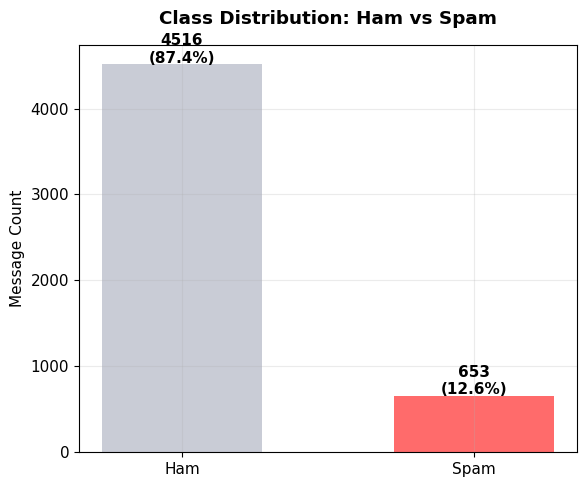

In [11]:
# class distribution
counts = df["label"].value_counts().sort_index()
labels = ["Ham", "Spam"]

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(labels, counts.values, color=["#c9ccd6", "#ff6b6b"], width=0.55)
for bar, val in zip(bars, counts.values):
    pct = val / counts.sum() * 100
    ax.text(bar.get_x() + bar.get_width() / 2, val + 20, f"{val}\n({pct:.1f}%)",
             ha="center", fontweight="bold")
ax.set_ylabel("Message Count")
ax.set_title("Class Distribution: Ham vs Spam", fontweight="bold", pad=15)
fig.tight_layout()
fig.savefig(f"{OUT_DIR}/class_distribution.png", dpi=150)
plt.show()

In [13]:
# process text and vectorize
def preprocess(text: str) -> str:
    text = text.lower().translate(PUNCT_TABLE)
    tokens = re.findall(r"\b[a-z]+\b", text)
    tokens = [t for t in tokens if t not in STOP_WORDS]
    return " ".join(tokens)

df["clean_text"] = df["text"].apply(preprocess)

tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(df["clean_text"]).toarray()
y = df["label"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (4135, 5000), Test: (1034, 5000)


In [14]:
#Train 4 models
logreg = LogisticRegression(max_iter=1000, class_weight="balanced")
logreg.fit(X_train, y_train)

nb = MultinomialNB()
nb.fit(X_train, y_train)

svm = CalibratedClassifierCV(LinearSVC(class_weight="balanced", max_iter=5000), cv=3)
svm.fit(X_train, y_train)

rf = RandomForestClassifier(
    n_estimators=300, max_depth=None, class_weight="balanced",
    random_state=42, n_jobs=-1,
)
rf.fit(X_train, y_train)

models = {"Logistic Regression": logreg, "Naive Bayes": nb, "SVM": svm, "Random Forest": rf}
print("Trained:", list(models.keys()))

Trained: ['Logistic Regression', 'Naive Bayes', 'SVM', 'Random Forest']


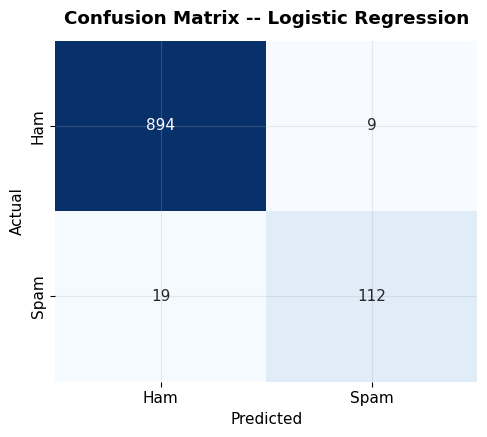


=== Logistic Regression (threshold=0.5) ===
Precision (spam): 0.926
Recall (spam):    0.855
F1 (spam):        0.889
Accuracy:         0.973
ROC-AUC:          0.987


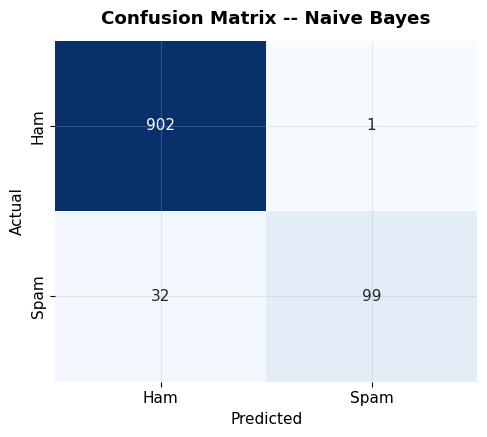


=== Naive Bayes (threshold=0.5) ===
Precision (spam): 0.990
Recall (spam):    0.756
F1 (spam):        0.857
Accuracy:         0.968
ROC-AUC:          0.977


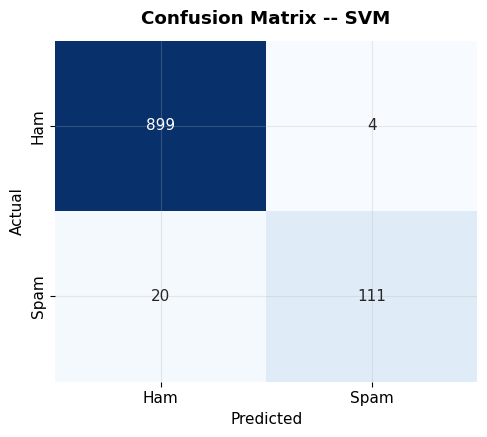


=== SVM (threshold=0.5) ===
Precision (spam): 0.965
Recall (spam):    0.847
F1 (spam):        0.902
Accuracy:         0.977
ROC-AUC:          0.986


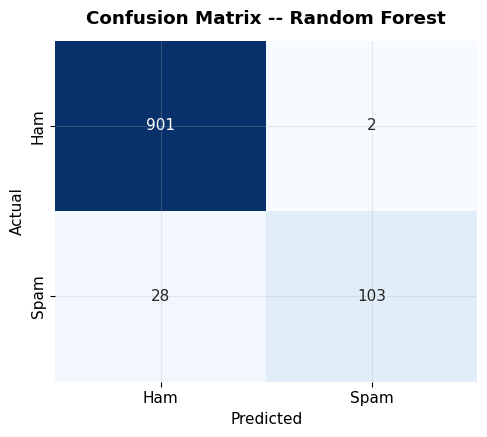


=== Random Forest (threshold=0.5) ===
Precision (spam): 0.981
Recall (spam):    0.786
F1 (spam):        0.873
Accuracy:         0.971
ROC-AUC:          0.989


In [15]:
# Evaluation
def plot_confusion_matrix(cm, model_name):
    fig, ax = plt.subplots(figsize=(5, 4.5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Ham", "Spam"], yticklabels=["Ham", "Spam"], ax=ax, cbar=False)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(f"Confusion Matrix -- {model_name}", fontweight="bold", pad=12)
    fig.tight_layout()
    fname = model_name.lower().replace(" ", "_")
    fig.savefig(f"{OUT_DIR}/confusion_matrix_{fname}.png", dpi=150)
    plt.show()


def evaluate_model(name, model, X_test, y_test) -> dict:
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)

    auc = roc_auc_score(y_test, y_prob)
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    cm = confusion_matrix(y_test, y_pred)

    plot_confusion_matrix(cm, name)

    return {
        "model": name,
        "precision_spam": report["1"]["precision"],
        "recall_spam": report["1"]["recall"],
        "f1_spam": report["1"]["f1-score"],
        "accuracy": report["accuracy"],
        "roc_auc": auc,
        "y_prob": y_prob,
    }


all_results = {}
for name, model in models.items():
    r = evaluate_model(name, model, X_test, y_test)
    all_results[name] = r
    print(f"\n=== {name} (threshold=0.5) ===")
    print(f"Precision (spam): {r['precision_spam']:.3f}")
    print(f"Recall (spam):    {r['recall_spam']:.3f}")
    print(f"F1 (spam):        {r['f1_spam']:.3f}")
    print(f"Accuracy:         {r['accuracy']:.3f}")
    print(f"ROC-AUC:          {r['roc_auc']:.3f}")

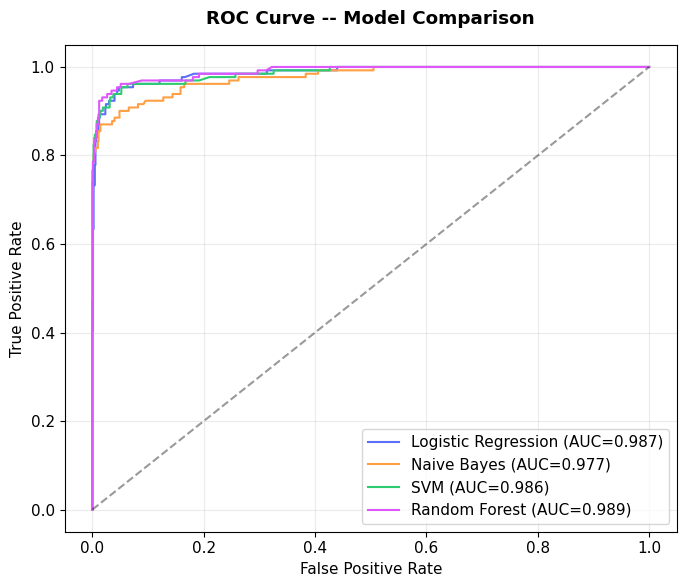

In [16]:
# ROC Curve
fig, ax = plt.subplots(figsize=(7, 6))
colors = {"Logistic Regression": "#5b6ffb", "Naive Bayes": "#ff9f43", "SVM": "#2ecc71", "Random Forest": "#e056fd"}
for name, r in all_results.items():
    fpr, tpr, _ = roc_curve(y_test, r["y_prob"])
    ax.plot(fpr, tpr, label=f"{name} (AUC={r['roc_auc']:.3f})", color=colors.get(name))
ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve -- Model Comparison", fontweight="bold", pad=15)
ax.legend()
fig.tight_layout()
fig.savefig(f"{OUT_DIR}/roc_curve.png", dpi=150)
plt.show()

In [17]:
# Selecting best model
auc_values = {k: v["roc_auc"] for k, v in all_results.items()}
top_auc = max(auc_values.values())
auc_tied = [k for k, v in auc_values.items() if top_auc - v < 0.005]

if len(auc_tied) > 1:
    best_model_name = max(auc_tied, key=lambda k: all_results[k]["f1_spam"])
    print(f"Models tied on ROC-AUC (within 0.005): {auc_tied}")
    print(f"Tiebreak by F1 -> best model: {best_model_name}")
else:
    best_model_name = max(all_results, key=lambda k: all_results[k]["roc_auc"])
    print(f"Best model by ROC-AUC: {best_model_name}")

best = all_results[best_model_name]

Models tied on ROC-AUC (within 0.005): ['Logistic Regression', 'SVM', 'Random Forest']
Tiebreak by F1 -> best model: SVM


Best model: SVM
Cost-optimal threshold: 0.62


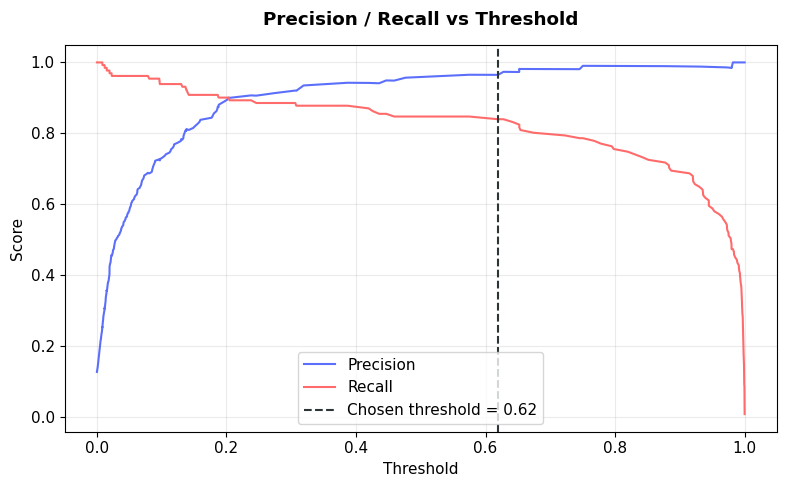


=== SVM at cost-optimal threshold 0.62 ===
Precision (spam): 0.973
Recall (spam):    0.840
F1 (spam):        0.902
Confusion matrix:
[[900   3]
 [ 21 110]]


In [18]:
# Cost Optimal Threshold
def find_cost_optimal_threshold(y_test, y_prob, cost_fn=COST_FALSE_NEGATIVE, cost_fp=COST_FALSE_POSITIVE):
    thresholds = np.linspace(0.01, 0.99, 99)
    best_threshold, best_cost = 0.5, np.inf
    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        fn = np.sum((y_pred == 0) & (y_test == 1))
        fp = np.sum((y_pred == 1) & (y_test == 0))
        cost = fn * cost_fn + fp * cost_fp
        if cost < best_cost:
            best_cost = cost
            best_threshold = t
    return best_threshold, best_cost


best_threshold, best_cost = find_cost_optimal_threshold(y_test, best["y_prob"])
print(f"Best model: {best_model_name}")
print(f"Cost-optimal threshold: {best_threshold:.2f}")

# Precision/Recall vs threshold, with the chosen point marked
precision, recall, thresholds = precision_recall_curve(y_test, best["y_prob"])
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(thresholds, precision[:-1], label="Precision", color="#5b6ffb")
ax.plot(thresholds, recall[:-1], label="Recall", color="#ff6b6b")
ax.axvline(best_threshold, color="#2d3436", linestyle="--", label=f"Chosen threshold = {best_threshold:.2f}")
ax.set_xlabel("Threshold")
ax.set_ylabel("Score")
ax.set_title("Precision / Recall vs Threshold", fontweight="bold", pad=15)
ax.legend()
fig.tight_layout()
fig.savefig(f"{OUT_DIR}/precision_recall_vs_threshold.png", dpi=150)
plt.show()

y_pred_opt = (best["y_prob"] >= best_threshold).astype(int)
report_opt = classification_report(y_test, y_pred_opt, output_dict=True, zero_division=0)
cm_opt = confusion_matrix(y_test, y_pred_opt)
print(f"\n=== {best_model_name} at cost-optimal threshold {best_threshold:.2f} ===")
print(f"Precision (spam): {report_opt['1']['precision']:.3f}")
print(f"Recall (spam):    {report_opt['1']['recall']:.3f}")
print(f"F1 (spam):        {report_opt['1']['f1-score']:.3f}")
print(f"Confusion matrix:\n{cm_opt}")

In [19]:
# Metric summary
rows = []
for name, r in all_results.items():
    rows.append({
        "Model": name, "Threshold": 0.5,
        "Precision (spam)": round(r["precision_spam"], 3),
        "Recall (spam)": round(r["recall_spam"], 3),
        "F1 (spam)": round(r["f1_spam"], 3),
        "Accuracy": round(r["accuracy"], 3),
        "ROC-AUC": round(r["roc_auc"], 3),
    })
rows.append({
    "Model": f"{best_model_name} (cost-optimized)",
    "Threshold": round(best_threshold, 2),
    "Precision (spam)": round(report_opt["1"]["precision"], 3),
    "Recall (spam)": round(report_opt["1"]["recall"], 3),
    "F1 (spam)": round(report_opt["1"]["f1-score"], 3),
    "Accuracy": round(report_opt["accuracy"], 3),
    "ROC-AUC": round(best["roc_auc"], 3),
})

metrics_df = pd.DataFrame(rows)
metrics_df.to_csv(f"{OUT_DIR}/metrics_summary.csv", index=False)
with open(f"{OUT_DIR}/metrics_summary.md", "w") as f:
    f.write("# Spam Detection -- Metrics Summary\n\n")
    f.write(metrics_df.to_markdown(index=False))
    f.write("\n")

metrics_df

,Model,Threshold,Precision (spam),Recall (spam),F1 (spam),Accuracy,ROC-AUC
0,Logistic Regression,0.50,0.926,0.855,0.889,0.973,0.987
1,Naive Bayes,0.50,0.990,0.756,0.857,0.968,0.977
2,SVM,0.50,0.965,0.847,0.902,0.977,0.986
3,Random Forest,0.50,0.981,0.786,0.873,0.971,0.989
4,SVM (cost-optimized),0.62,0.973,0.840,0.902,0.977,0.986


In [20]:
# Try on Custom message
sample_msg = "Congratulations! You won a free gift card. Click now"
sample_clean = preprocess(sample_msg)
sample_vec = tfidf.transform([sample_clean])

best_model_obj = models[best_model_name]
spam_prob = best_model_obj.predict_proba(sample_vec)[0][1]
verdict = "SPAM" if spam_prob >= best_threshold else "HAM"

print(f"Message: {sample_msg}")
print(f"Spam probability: {spam_prob:.3f}")
print(f"Verdict at threshold {best_threshold:.2f}: {verdict}")

Message: Congratulations! You won a free gift card. Click now
Spam probability: 0.988
Verdict at threshold 0.62: SPAM


In [21]:
# download outputs
import shutil
from google.colab import files

shutil.make_archive("outputs", "zip", OUT_DIR)
files.download("outputs.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>